# Direct Transfer Summary Table

This notebook reads the copied transition logs from `logs/sim2real_transitions/presslight` and summarizes the available comparison methods:

- `direct_transfer` for each network and setting
- `domain_randomization` for each network and setting
- `gat` for each network and setting
- `ugat` for each network and setting
- `jlgat` for each network and setting

Method-specific metric rules:

- `direct_transfer`: `FINAL_TEST` travel time from the latest copied SUMO direct-transfer DTL log
- `domain_randomization`: prefer explicit eval logs with `TEST_REAL` at episode `0`; fall back to the copied training logs with `TEST_REAL` at episode `0`, then `200` for older setting4 logs
- `gat`, `ugat`, `jlgat`: the lowest `Real rollout` average travel time found in the copied DTL log for that network and setting

`cityflow_direct_transfer` is still loaded internally as the baseline used to compute gaps, but it is not shown as a comparison method in the gap table or plots.


In [1]:
from pathlib import Path
import re
import numpy as np

import pandas as pd

LOG_ROOT = Path("logs/sim2real_transitions/presslight")

NETWORK_ORDER = [
    "tempe_1x1",
    "bullhead_1",
    "cologne1",
    "ingolstadt1",
    "hz1x1",
    "tempe_16",
    "bullhead_3",
    "cologne3",
    "ingolstadt7",
    "hz4x4",
]

SETTING_ORDER = ["setting1", "setting2", "setting3", "setting4"]
METHOD_ORDER = [
    "direct_transfer",
    "domain_randomization",
    "gat",
    "ugat",
    "jlgat",
]

COLUMNS = [
    "exp_name",
    "mode",
    "episode",
    "travel_time",
    "aux",
    "reward",
    "queue",
    "delay",
    "throughput",
]

TEXT_REAL_ROLLOUT_RE = re.compile(r"^Real rollout step:(?P<episode>\d+)/\d+, travel time:(?P<travel_time>-?\d+(?:\.\d+)?)")


In [2]:
# NETWORK_ORDER = ["bullhead_3"]
# SETTING_ORDER = ["setting2"]


In [3]:
def read_direct_transfer_final_test(log_path: Path):
    df = pd.read_csv(log_path, sep="\t", header=None, names=COLUMNS)
    df["episode"] = pd.to_numeric(df["episode"], errors="coerce")
    df["travel_time"] = pd.to_numeric(df["travel_time"], errors="coerce")
    df["throughput"] = pd.to_numeric(df["throughput"], errors="coerce")
    final_df = df[df["mode"] == "FINAL_TEST"].copy()
    if final_df.empty:
        return pd.NA, pd.NA, pd.NA
    final_row = final_df.iloc[-1]
    episode = pd.to_numeric(final_row["episode"], errors="coerce")
    episode = int(episode) if pd.notna(episode) else pd.NA
    throughput = pd.to_numeric(final_row["throughput"], errors="coerce")
    throughput = float(throughput) if pd.notna(throughput) else pd.NA
    return float(final_row["travel_time"]), episode, throughput


def read_domain_randomization_result(network: str, setting: str):
    candidate_dirs = [
        LOG_ROOT / network / "domain_randomization_eval" / setting,
        LOG_ROOT / network / "domain_randomization" / setting,
    ]

    for log_dir in candidate_dirs:
        log_files = sorted(log_dir.glob("*_DTL.log"))
        if not log_files:
            continue

        for log_path in reversed(log_files):
            df = pd.read_csv(log_path, sep="\t", header=None, names=COLUMNS)
            df["episode"] = pd.to_numeric(df["episode"], errors="coerce")
            df["travel_time"] = pd.to_numeric(df["travel_time"], errors="coerce")

            eval_df = df[(df["mode"] == "TEST_REAL") & (df["episode"] == 0)]
            if not eval_df.empty:
                eval_row = eval_df.iloc[-1]
                throughput = pd.to_numeric(eval_row["throughput"], errors="coerce")
                throughput = float(throughput) if pd.notna(throughput) else pd.NA
                return float(eval_row["travel_time"]), 0, throughput, log_path.name

        for log_path in reversed(log_files):
            df = pd.read_csv(log_path, sep="\t", header=None, names=COLUMNS)
            df["episode"] = pd.to_numeric(df["episode"], errors="coerce")
            df["travel_time"] = pd.to_numeric(df["travel_time"], errors="coerce")
            eval_df = df[(df["mode"] == "TEST_REAL") & (df["episode"] == 200)]
            if not eval_df.empty:
                eval_row = eval_df.iloc[-1]
                throughput = pd.to_numeric(eval_row["throughput"], errors="coerce")
                throughput = float(throughput) if pd.notna(throughput) else pd.NA
                return float(eval_row["travel_time"]), 200, throughput, log_path.name

    return pd.NA, pd.NA, pd.NA, pd.NA


def read_lowest_real_rollout(log_path: Path):
    text = log_path.read_text().strip()
    if not text:
        return pd.NA, pd.NA, pd.NA

    first_line = text.splitlines()[0]
    best = None

    if "	" in first_line:
        df = pd.read_csv(log_path, sep="\t", header=None, names=COLUMNS)
        df["travel_time"] = pd.to_numeric(df["travel_time"], errors="coerce")
        df["throughput"] = pd.to_numeric(df["throughput"], errors="coerce")
        real_df = df[df["mode"] == "Real rollout"].copy()
        if real_df.empty:
            return pd.NA, pd.NA, pd.NA
        best_row = real_df.loc[real_df["travel_time"].idxmin()]
        best_value = float(best_row["travel_time"]) if pd.notna(best_row["travel_time"]) else pd.NA
        best_episode = pd.to_numeric(best_row["episode"], errors="coerce")
        best_episode = int(best_episode) if pd.notna(best_episode) else pd.NA
        best_throughput = pd.to_numeric(best_row["throughput"], errors="coerce")
        best_throughput = float(best_throughput) if pd.notna(best_throughput) else pd.NA
        return best_value, best_episode, best_throughput

    best_episode = pd.NA
    best_throughput = pd.NA

    for line in text.splitlines():
        match = TEXT_REAL_ROLLOUT_RE.match(line.strip())
        if match:
            value = float(match.group("travel_time"))
            if best is None or value < best:
                best = value
                best_episode = int(match.group("episode"))

    return (float(best), best_episode, best_throughput) if best is not None else (pd.NA, pd.NA, pd.NA)


def format_method_cell(value, episode, throughput):
    if pd.isna(value):
        return pd.NA
    if pd.isna(episode) and pd.isna(throughput):
        return f"{value:.1f}"
    parts = []
    if pd.notna(throughput):
        parts.append(f"tp {int(throughput)}" if float(throughput).is_integer() else f"tp {throughput:.1f}")
    if pd.notna(episode):
        parts.append(f"ep {int(episode)}")
    details = ", ".join(parts)
    return f"{value:.1f} ({details})" if details else f"{value:.1f}"


method_rows = []
for network in NETWORK_ORDER:
    cityflow_log_files = sorted((LOG_ROOT / network / "cityflow_direct_transfer").glob("*_DTL.log"))
    cityflow_value, cityflow_episode, cityflow_throughput = read_direct_transfer_final_test(cityflow_log_files[-1]) if cityflow_log_files else (pd.NA, pd.NA, pd.NA)
    cityflow_log = cityflow_log_files[-1].name if cityflow_log_files else pd.NA

    for setting in SETTING_ORDER:
        row = {
            "network": network,
            "setting": setting,
            "cityflow_direct_transfer": cityflow_value,
            "cityflow_direct_transfer_episode": cityflow_episode,
            "cityflow_direct_transfer_throughput": cityflow_throughput,
            "cityflow_direct_transfer_log_file": cityflow_log,
        }

        sumo_log_files = sorted((LOG_ROOT / network / "sumo_direct_transfer" / setting).glob("*_DTL.log"))
        if sumo_log_files:
            row["direct_transfer"], row["direct_transfer_episode"], row["direct_transfer_throughput"] = read_direct_transfer_final_test(sumo_log_files[-1])
            row["direct_transfer_log_file"] = sumo_log_files[-1].name
        else:
            row["direct_transfer"] = pd.NA
            row["direct_transfer_episode"] = pd.NA
            row["direct_transfer_throughput"] = pd.NA
            row["direct_transfer_log_file"] = pd.NA

        dr_value, dr_episode, dr_throughput, dr_log = read_domain_randomization_result(network, setting)
        row["domain_randomization"] = dr_value
        row["domain_randomization_episode"] = dr_episode
        row["domain_randomization_throughput"] = dr_throughput
        row["domain_randomization_log_file"] = dr_log

        for method in ["gat", "ugat", "jlgat"]:
            method_dir = LOG_ROOT / network / method / setting
            log_files = sorted(method_dir.glob("*_DTL.log"))
            if not log_files:
                row[method] = pd.NA
                row[f"{method}_episode"] = pd.NA
                row[f"{method}_throughput"] = pd.NA
                row[f"{method}_log_file"] = pd.NA
                continue

            log_path = log_files[-1]
            row[method], row[f"{method}_episode"], row[f"{method}_throughput"] = read_lowest_real_rollout(log_path)
            row[f"{method}_log_file"] = log_path.name

        method_rows.append(row)

method_df = pd.DataFrame(method_rows)
method_df = method_df.round(1)
method_df


,network,setting,cityflow_direct_transfer,cityflow_direct_transfer_episode,cityflow_direct_transfer_throughput,cityflow_direct_transfer_log_file,direct_transfer,direct_transfer_episode,direct_transfer_throughput,direct_transfer_log_file,...,gat_throughput,gat_log_file,ugat,ugat_episode,ugat_throughput,ugat_log_file,jlgat,jlgat_episode,jlgat_throughput,jlgat_log_file
0,tempe_1x1,setting1,143.0,0,1873.0,2026_04_15-19_37_21_DTL.log,176.2,0,1751.0,2026_04_20-13_24_39_DTL.log,...,1819.0,2026_04_16-00_49_18_DTL.log,164.4,5,1824.0,2026_04_16-01_54_40_DTL.log,<NA>,<NA>,<NA>,<NA>
1,tempe_1x1,setting2,143.0,0,1873.0,2026_04_15-19_37_21_DTL.log,178.8,0,1812.0,2026_04_20-13_24_42_DTL.log,...,1822.0,2026_04_16-01_02_43_DTL.log,166.2,8,1830.0,2026_04_16-02_08_15_DTL.log,<NA>,<NA>,<NA>,<NA>
2,tempe_1x1,setting3,143.0,0,1873.0,2026_04_15-19_37_21_DTL.log,189.0,0,1813.0,2026_04_20-13_24_45_DTL.log,...,1821.0,2026_04_16-01_16_25_DTL.log,170.6,94,1823.0,2026_04_16-02_21_26_DTL.log,<NA>,<NA>,<NA>,<NA>
3,tempe_1x1,setting4,143.0,0,1873.0,2026_04_15-19_37_21_DTL.log,285.3,0,1504.0,2026_04_20-13_24_48_DTL.log,...,116.0,2026_04_16-01_30_28_DTL.log,189.1,72,170.0,2026_04_16-02_33_47_DTL.log,<NA>,<NA>,<NA>,<NA>
4,bullhead_1,setting1,121.0,0,1399.0,2026_04_15-19_37_27_DTL.log,139.5,0,1368.0,2026_04_20-13_24_52_DTL.log,...,1370.0,2026_04_16-00_49_18_DTL.log,123.1,77,67.0,2026_04_16-04_04_22_DTL.log,<NA>,<NA>,<NA>,<NA>
5,bullhead_1,setting2,121.0,0,1399.0,2026_04_15-19_37_27_DTL.log,139.1,0,1370.0,2026_04_20-13_24_55_DTL.log,...,1371.0,2026_04_16-03_34_10_DTL.log,123.8,98,723.0,2026_04_16-04_16_03_DTL.log,<NA>,<NA>,<NA>,<NA>
6,bullhead_1,setting3,121.0,0,1399.0,2026_04_15-19_37_27_DTL.log,143.1,0,1303.0,2026_04_20-13_24_58_DTL.log,...,1303.0,2026_04_16-03_43_35_DTL.log,142.3,25,1302.0,2026_04_16-04_26_39_DTL.log,<NA>,<NA>,<NA>,<NA>
7,bullhead_1,setting4,121.0,0,1399.0,2026_04_15-19_37_27_DTL.log,152.3,0,1191.0,2026_04_20-13_25_00_DTL.log,...,1191.0,2026_04_16-03_52_48_DTL.log,152.3,0,1191.0,2026_04_16-04_36_29_DTL.log,<NA>,<NA>,<NA>,<NA>
8,cologne1,setting1,42.1,0,2000.0,2026_04_15-19_37_32_DTL.log,131.4,0,1802.0,2026_04_20-13_25_03_DTL.log,...,268.0,2026_04_16-00_49_19_DTL.log,86.0,26,302.0,2026_04_16-02_51_44_DTL.log,<NA>,<NA>,<NA>,<NA>
9,cologne1,setting2,42.1,0,2000.0,2026_04_15-19_37_32_DTL.log,149.3,0,1763.0,2026_04_20-13_25_06_DTL.log,...,300.0,2026_04_16-02_20_36_DTL.log,84.6,28,326.0,2026_04_16-03_01_35_DTL.log,<NA>,<NA>,<NA>,<NA>


In [4]:
method_table_df = method_df.set_index(["network", "setting"])[METHOD_ORDER].sort_index()
method_episode_df = method_df.set_index(["network", "setting"])[[f"{method}_episode" for method in METHOD_ORDER]].sort_index()
method_episode_df.columns = METHOD_ORDER
method_throughput_df = method_df.set_index(["network", "setting"])[[f"{method}_throughput" for method in METHOD_ORDER]].sort_index()
method_throughput_df.columns = METHOD_ORDER
method_table_display_df = method_table_df.copy()
for method in METHOD_ORDER:
    method_table_display_df[method] = [
        format_method_cell(value, episode, throughput)
        for value, episode, throughput in zip(method_table_df[method], method_episode_df[method], method_throughput_df[method])
    ]

method_throughput_display_df = method_throughput_df.copy()
for method in METHOD_ORDER:
    method_throughput_display_df[method] = [
        (int(value) if pd.notna(value) and float(value).is_integer() else round(float(value), 1)) if pd.notna(value) else pd.NA
        for value in method_throughput_df[method]
    ]

display(method_table_display_df)
display(method_throughput_display_df)


direct_transfer    domain_randomization  \
network     setting                                                    
bullhead_1  setting1   139.5 (tp 1368, ep 0)   153.1 (tp 1361, ep 0)   
            setting2   139.1 (tp 1370, ep 0)   152.9 (tp 1360, ep 0)   
            setting3   143.1 (tp 1303, ep 0)   156.3 (tp 1296, ep 0)   
            setting4   152.3 (tp 1191, ep 0)   163.5 (tp 1183, ep 0)   
bullhead_3  setting1    190.8 (tp 585, ep 0)   171.9 (tp 3384, ep 0)   
            setting2    227.6 (tp 235, ep 0)   169.4 (tp 3321, ep 0)   
            setting3    214.9 (tp 718, ep 0)   368.0 (tp 2771, ep 0)   
            setting4    362.8 (tp 199, ep 0)   335.7 (tp 2536, ep 0)   
cologne1    setting1   131.4 (tp 1802, ep 0)   180.5 (tp 1700, ep 0)   
            setting2   149.3 (tp 1763, ep 0)    176.2 (tp 844, ep 0)   
            setting3    126.0 (tp 414, ep 0)   183.1 (tp 1677, ep 0)   
            setting4   209.7 (tp 1521, ep 0)   243.1 (tp 1421, ep 0)   
cologne3    setting1    94.9 (tp 1058, ep 0)                    <NA>   
            setting2    96.9 (tp 1094, ep 0)                    <NA>   
            setting3   100.0 (tp 1110, ep 0)                    <NA>   
            setting4   194.4 (tp 1124, ep 0)                    <NA>   
hz1x1       setting1   184.0 (tp 1798, ep 0)   153.2 (tp 1087, ep 0)   
            setting2   187.0 (tp 1805, ep 0)   211.9 (tp 1114, ep 0)   
            setting3   192.6 (tp 1785, ep 0)   155.6 (tp 1094, ep 0)   
            setting4   250.5 (tp 1637, ep 0)   160.0 (tp 1020, ep 0)   
hz4x4       setting1   418.8 (tp 2655, ep 0)   428.2 (tp 2669, ep 0)   
            setting2   419.2 (tp 2650, ep 0)   420.7 (tp 2660, ep 0)   
            setting3   424.2 (tp 2599, ep 0)   427.7 (tp 2584, ep 0)   
            setting4   437.2 (tp 2424, ep 0)   435.2 (tp 2402, ep 0)   
ingolstadt1 setting1   103.8 (tp 1230, ep 0)    88.0 (tp 1434, ep 0)   
            setting2   114.1 (tp 1237, ep 0)    96.2 (tp 1410, ep 0)   
            setting3    89.3 (tp 1225, ep 0)    73.6 (tp 1210, ep 0)   
            setting4    61.3 (tp 1077, ep 0)    104.8 (tp 907, ep 0)   
ingolstadt7 setting1     90.1 (tp 916, ep 0)     83.9 (tp 888, ep 0)   
            setting2     99.3 (tp 941, ep 0)     82.7 (tp 894, ep 0)   
            setting3     95.6 (tp 940, ep 0)    101.0 (tp 917, ep 0)   
            setting4    127.8 (tp 943, ep 0)    120.3 (tp 842, ep 0)   
tempe_16    setting1  105.2 (tp 18723, ep 0)  104.2 (tp 18589, ep 0)   
            setting2  104.2 (tp 18730, ep 0)  104.0 (tp 18642, ep 0)   
            setting3  120.8 (tp 17939, ep 0)  114.4 (tp 18041, ep 0)   
            setting4  165.7 (tp 15652, ep 0)  141.1 (tp 15495, ep 0)   
tempe_1x1   setting1   176.2 (tp 1751, ep 0)   176.7 (tp 1821, ep 0)   
            setting2   178.8 (tp 1812, ep 0)   176.9 (tp 1825, ep 0)   
            setting3   189.0 (tp 1813, ep 0)   187.9 (tp 1813, ep 0)   
            setting4   285.3 (tp 1504, ep 0)   243.2 (tp 1011, ep 0)   

                                          gat                     ugat  \
network     setting                                                      
bullhead_1  setting1   131.8 (tp 1370, ep 58)     123.1 (tp 67, ep 77)   
            setting2   137.8 (tp 1371, ep 66)    123.8 (tp 723, ep 98)   
            setting3   134.9 (tp 1303, ep 54)   142.3 (tp 1302, ep 25)   
            setting4    152.3 (tp 1191, ep 0)    152.3 (tp 1191, ep 0)   
bullhead_3  setting1   145.2 (tp 1625, ep 88)   150.0 (tp 3126, ep 58)   
            setting2   127.4 (tp 1260, ep 25)   147.1 (tp 1649, ep 27)   
            setting3   148.8 (tp 2651, ep 15)    139.7 (tp 555, ep 84)   
            setting4   148.2 (tp 1099, ep 99)   166.3 (tp 2722, ep 23)   
cologne1    setting1     77.9 (tp 268, ep 55)     86.0 (tp 302, ep 26)   
            setting2     85.9 (tp 300, ep 92)     84.6 (tp 326, ep 28)   
            setting3     83.3 (tp 276, ep 53)     78.3 (tp 238, ep 41)   
            setting4     83.1 (tp 626, ep 

direct_transfer domain_randomization    gat   ugat  \
network     setting                                                        
bullhead_1  setting1             1368                 1361   1370     67   
            setting2             1370                 1360   1371    723   
            setting3             1303                 1296   1303   1302   
            setting4             1191                 1183   1191   1191   
bullhead_3  setting1              585                 3384   1625   3126   
            setting2              235                 3321   1260   1649   
            setting3              718                 2771   2651    555   
            setting4              199                 2536   1099   2722   
cologne1    setting1             1802                 1700    268    302   
            setting2             1763                  844    300    326   
            setting3              414                 1677    276    238   
            setting4             1521                 1421    626    228   
cologne3    setting1             1058                 <NA>    722   1065   
            setting2             1094                 <NA>    661   1014   
            setting3             1110                 <NA>    675    637   
            setting4             1124                 <NA>   1135   1113   
hz1x1       setting1             1798                 1087   1939   1932   
            setting2             1805                 1114   1883   1932   
            setting3             1785                 1094   1926   1906   
            setting4             1637                 1020   1815   1044   
hz4x4       setting1             2655                 2669   2671   <NA>   
            setting2             2650                 2660   <NA>   <NA>   
            setting3             2599                 2584   <NA>   <NA>   
            setting4             2424                 2402   <NA>   <NA>   
ingolstadt1 setting1             1230                 1434   1050   1182   
            setting2             1237                 1410    560   1152   
            setting3             1225                 1210   1133   1116   
            setting4             1077                  907   1083   1078   
ingolstadt7 setting1              916                  888    892    809   
            setting2              941                  894    824    761   
            setting3              940                  917    487    704   
            setting4              943                  842    709    375   
tempe_16    setting1            18723                18589  18730  18652   
            setting2            18730                18642  18526  18730   
            setting3            17939                18041  17860  18029   
            setting4            15652                15495  15235  15642   
tempe_1x1   setting1             1751                 1821   1819   1824   
            setting2             1812                 1825   1822   1830   
            setting3             1813                 1813   1821   1823   
            setting4             1504                 1011    116    170   

                      jlgat  
network     setting          
bullhead_1  setting1   <NA>  
            setting2   <NA>  
            setting3   <NA>  
            setting4   <NA>  
bullhead_3  setting1   3294  
            setting2    218  
            setting3   3158  
            setting4   2765  
cologne1    setting1   <NA>  
            setting2   <NA>  
            setting3   <NA>  
            setting4   <NA>  
cologne3    setting1   1024  
            setting2   1082  
            setting3    651  
            setting4    485  
hz1x1       setting1   <NA>  
            setting2   <NA>  
            setting3   <NA>  
            setting4   <NA>  
hz4x4       setting1   <NA>  
            setting2   <NA>  
            setting3   <NA>  
            setting4   <NA>  
ingolstadt1 setting1   <NA>  
            setting

## Method Availability

The table below shows which displayed comparison methods were found for each network and setting.


In [5]:
availability_rows = []
for network in NETWORK_ORDER:
    for setting in SETTING_ORDER:
        row = method_df[(method_df["network"] == network) & (method_df["setting"] == setting)]
        if row.empty:
            continue
        row = row.iloc[-1]
        availability_rows.append(
            {
                "network": network,
                "setting": setting,
                **{method: pd.notna(row[method]) for method in METHOD_ORDER},
            }
        )

availability_df = pd.DataFrame(availability_rows)
availability_df


,network,setting,direct_transfer,domain_randomization,gat,ugat,jlgat
0,tempe_1x1,setting1,True,True,True,True,False
1,tempe_1x1,setting2,True,True,True,True,False
2,tempe_1x1,setting3,True,True,True,True,False
3,tempe_1x1,setting4,True,True,True,True,False
4,bullhead_1,setting1,True,True,True,True,False
5,bullhead_1,setting2,True,True,True,True,False
6,bullhead_1,setting3,True,True,True,True,False
7,bullhead_1,setting4,True,True,True,True,False
8,cologne1,setting1,True,True,True,True,False
9,cologne1,setting2,True,True,True,True,False


## Gap Comparison

These comparisons include both raw travel time and a cityflow-referenced gap.
For each network and setting, the gap is computed as:

- `gap_vs_cityflow = method_travel_time - cityflow_direct_transfer`

`cityflow_direct_transfer` is used only as the baseline for the gap calculation and is not shown as a method in the table or plots.


In [6]:
comparison_rows = []
for _, row in method_df.iterrows():
    cityflow_reference = row.get("cityflow_direct_transfer", pd.NA)

    for method in METHOD_ORDER:
        value = row.get(method, pd.NA)
        if pd.isna(value):
            continue

        gap = pd.NA
        if pd.notna(cityflow_reference):
            gap = float(value - cityflow_reference)

        comparison_rows.append(
            {
                "network": row["network"],
                "setting": row["setting"],
                "method": method,
                "travel_time": value,
                "episode": row.get(f"{method}_episode", pd.NA),
                "throughput": row.get(f"{method}_throughput", pd.NA),
                "cityflow_direct_transfer": cityflow_reference,
                "gap_vs_cityflow": gap,
                "log_file": row.get(f"{method}_log_file", pd.NA),
            }
        )

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.round(1)
comparison_df = comparison_df[
    [
        "network",
        "setting",
        "method",
        "travel_time",
        "episode",
        "cityflow_direct_transfer",
        "gap_vs_cityflow",
        "log_file",
        "throughput",
    ]
]
comparison_df


,network,setting,method,travel_time,episode,cityflow_direct_transfer,gap_vs_cityflow,log_file,throughput
0,tempe_1x1,setting1,direct_transfer,176.2,0,143.0,33.2,2026_04_20-13_24_39_DTL.log,1751.0
1,tempe_1x1,setting1,domain_randomization,176.7,0,143.0,33.7,2026_04_20-14_21_11_DTL.log,1821.0
2,tempe_1x1,setting1,gat,165.9,6,143.0,22.9,2026_04_16-00_49_18_DTL.log,1819.0
3,tempe_1x1,setting1,ugat,164.4,5,143.0,21.4,2026_04_16-01_54_40_DTL.log,1824.0
4,tempe_1x1,setting2,direct_transfer,178.8,0,143.0,35.8,2026_04_20-13_24_42_DTL.log,1812.0
...,...,...,...,...,...,...,...,...,...
158,hz4x4,setting2,domain_randomization,420.7,0,349.4,71.3,2026_04_20-14_24_21_DTL.log,2660.0
159,hz4x4,setting3,direct_transfer,424.2,0,349.4,74.8,2026_04_20-13_28_53_DTL.log,2599.0
160,hz4x4,setting3,domain_randomization,427.7,0,349.4,78.3,2026_04_20-14_24_32_DTL.log,2584.0
161,hz4x4,setting4,direct_transfer,437.2,0,349.4,87.8,2026_04_20-13_29_03_DTL.log,2424.0


## Gap Bar Chart

Each chart shows all available displayed methods together for one network.
The plotted value is `method_travel_time - cityflow_direct_transfer`.
Missing methods are skipped automatically.


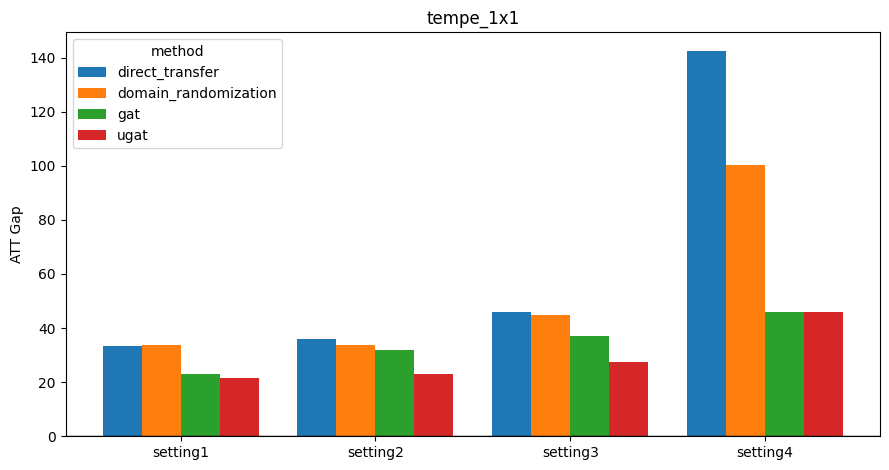

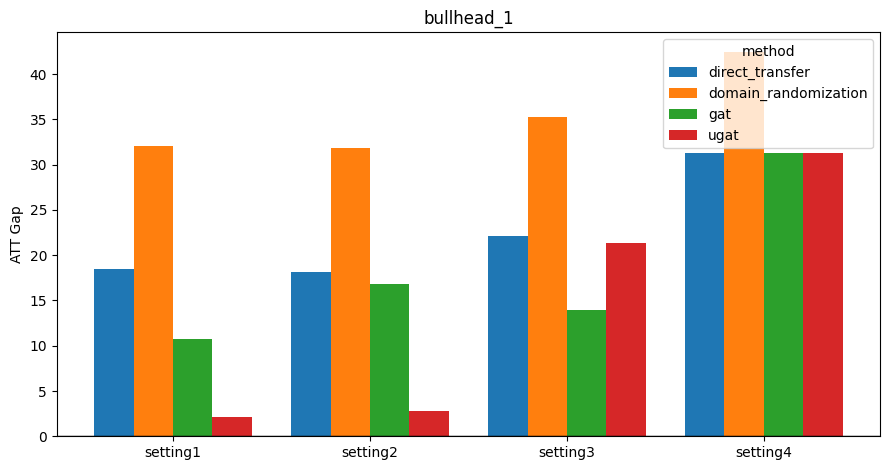

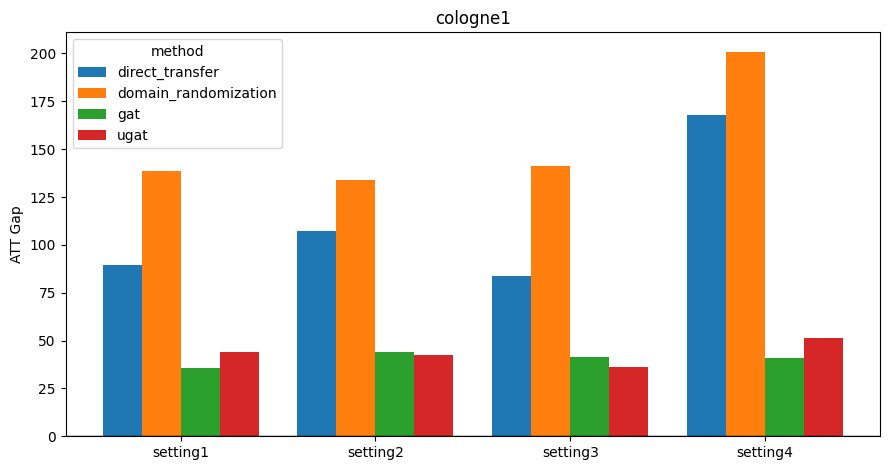

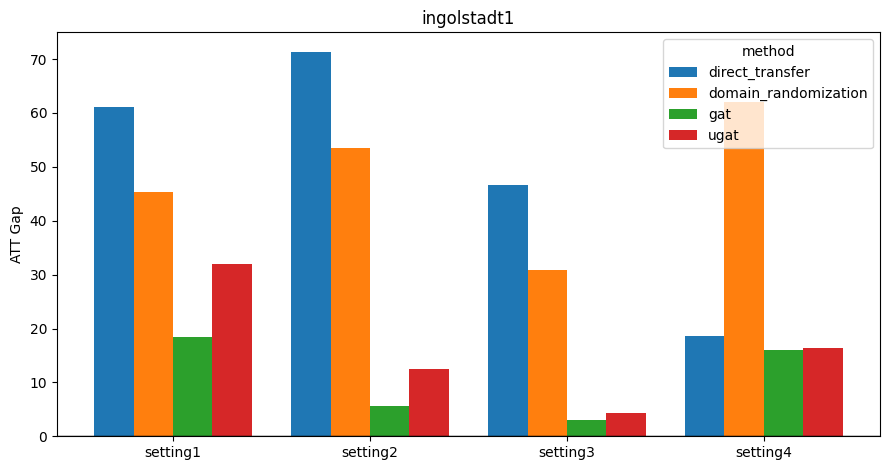

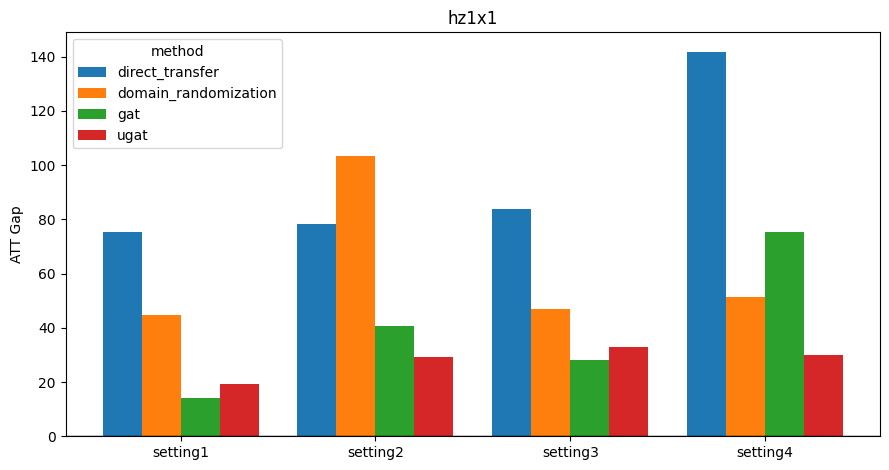

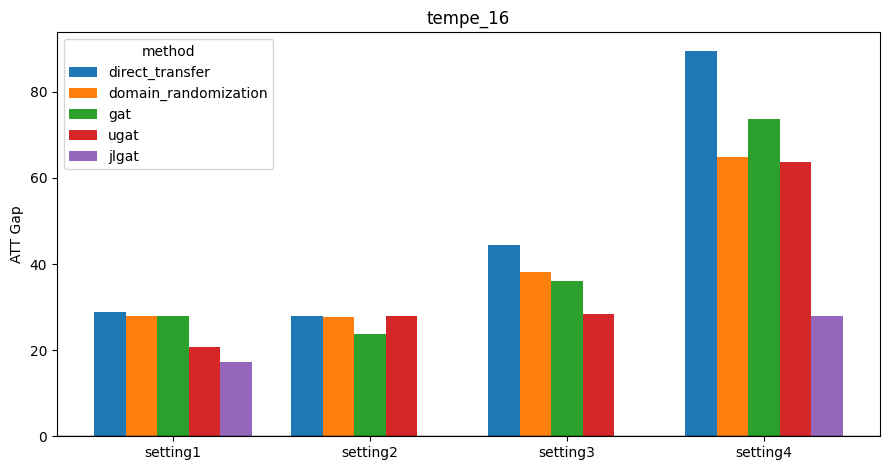

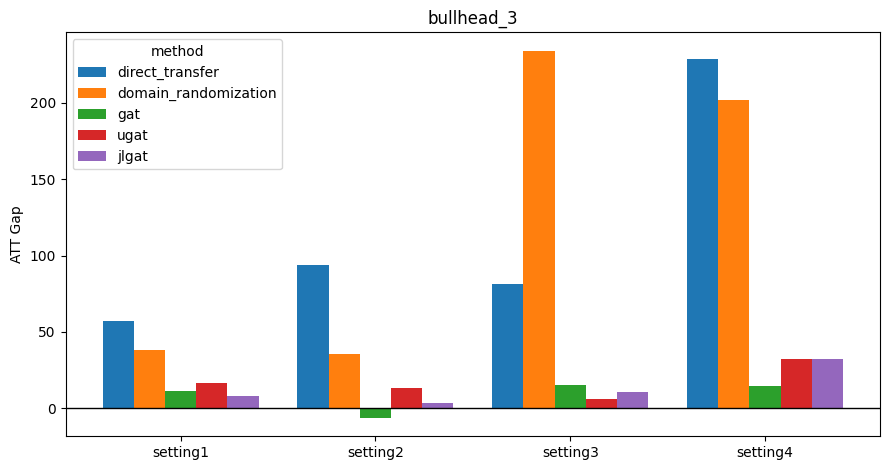

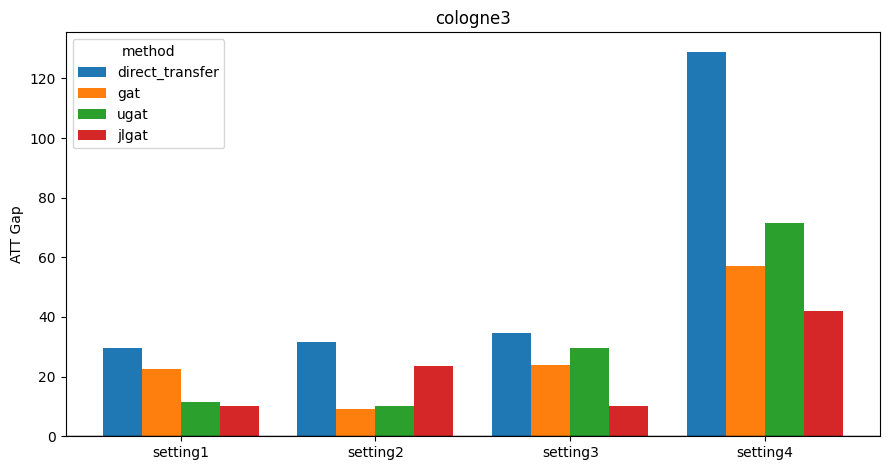

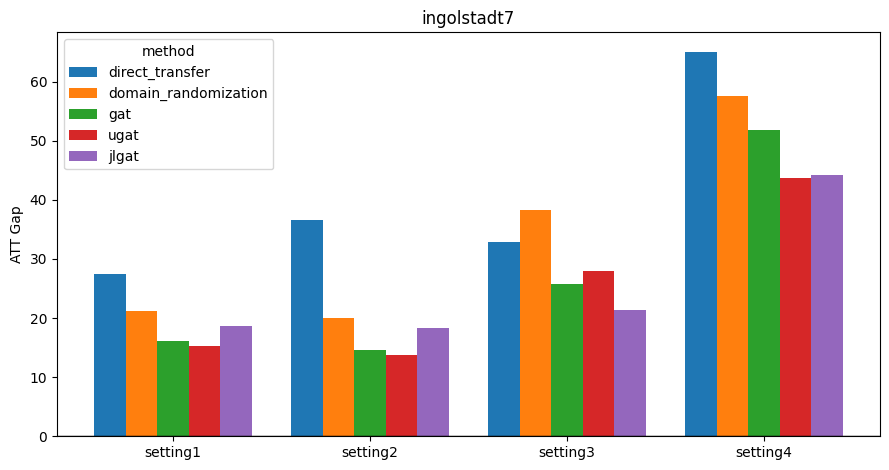

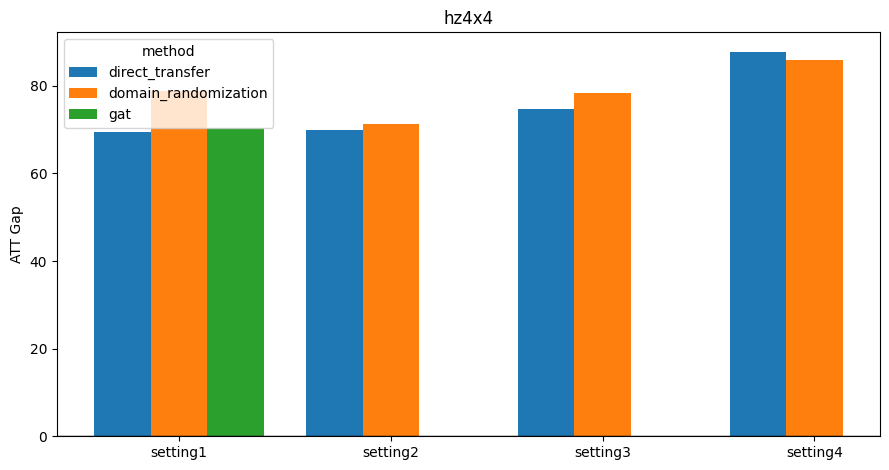

In [7]:
import matplotlib.pyplot as plt
import numpy as np

for network in NETWORK_ORDER:
    plot_df = comparison_df[comparison_df["network"] == network].copy()
    if plot_df.empty:
        continue

    pivot_df = (
        plot_df.pivot(index="setting", columns="method", values="gap_vs_cityflow")
        .reindex(SETTING_ORDER)
    )
    available_methods = [method for method in METHOD_ORDER if method in pivot_df.columns and pivot_df[method].notna().any()]
    if not available_methods:
        continue

    x = np.arange(len(SETTING_ORDER))
    width = 0.8 / len(available_methods)

    fig, ax = plt.subplots(figsize=(9, 4.8))
    for idx, method in enumerate(available_methods):
        offsets = x - 0.4 + width / 2 + idx * width
        values = pivot_df[method].to_numpy(dtype=float)
        mask = ~np.isnan(values)
        ax.bar(offsets[mask], values[mask], width=width, label=method)

    ax.axhline(0, color="black", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(SETTING_ORDER)
    ax.set_ylabel("ATT Gap")
    ax.set_title(network)
    ax.legend(title="method")
    fig.tight_layout()
    plt.show()


## Bullhead 3 Setting 2 Bar Chart

This separate bar-chart cell compares the selected `bullhead_3` / `setting2` method results using the same picked rows shown in the tables above.


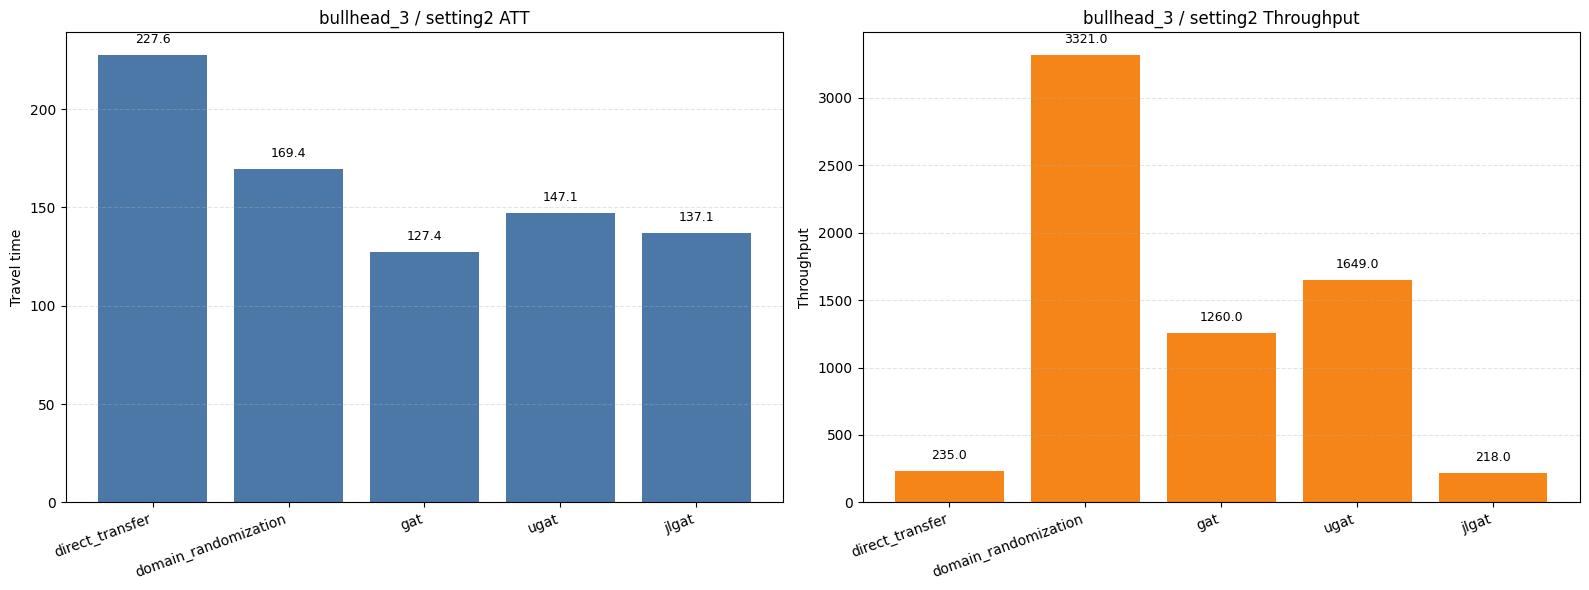

In [11]:
focus_df = comparison_df[
    (comparison_df["network"] == "bullhead_3")
    & (comparison_df["setting"] == "setting2")
].copy()

focus_df["method"] = pd.Categorical(focus_df["method"], categories=METHOD_ORDER, ordered=True)
focus_df = focus_df.sort_values("method")

if focus_df.empty:
    print("No comparison data found for bullhead_3 / setting2.")
else:
    labels = focus_df["method"].astype(str).tolist()
    att_values = pd.to_numeric(focus_df["travel_time"], errors="coerce").tolist()
    throughput_values = pd.to_numeric(focus_df["throughput"], errors="coerce").tolist()
    x = list(range(len(labels)))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].bar(x, att_values, color="#4C78A8")
    axes[0].set_title("bullhead_3 / setting2 ATT")
    axes[0].set_ylabel("Travel time")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels, rotation=20, ha="right")
    axes[0].grid(axis="y", linestyle="--", alpha=0.35)

    axes[1].bar(x, throughput_values, color="#F58518")
    axes[1].set_title("bullhead_3 / setting2 Throughput")
    axes[1].set_ylabel("Throughput")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, rotation=20, ha="right")
    axes[1].grid(axis="y", linestyle="--", alpha=0.35)

    for ax, values in zip(axes, [att_values, throughput_values]):
        finite_values = [value for value in values if pd.notna(value)]
        offset = (max(finite_values) * 0.02) if finite_values and max(finite_values) > 0 else 0.5
        for idx, value in enumerate(values):
            if pd.notna(value):
                ax.text(idx, value + offset, f"{value:.1f}", ha="center", va="bottom", fontsize=9)

    fig.tight_layout()
    plt.show()
